# MUSEUM ANALYSIS

In [7]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
df=pd.read_csv("../data/museums.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_27468\420788918.py:1: DtypeWarning: Columns (0: Zip Code (Administrative Location), 1: Phone Number, 2: Employer ID Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../data/museums.csv")


## 1. Introdução e Objetivos
Este projeto tem como objetivo analisar a base de dados dos museus para compreender melhor o cenário do setor cultural. A partir dessa análise, busca-se identificar padrões, tratar inconsistências nos dados e gerar informações que possam auxiliar na tomada de decisão do Nur Mah Museum.
>Antes de iniciar qualquer tratamento dos dados, é importante entender como a base está estruturada. Para isso, foram utilizadas algumas funções do Pandas que permitem visualizar a quantidade de registros, os tipos das colunas e algumas estatísticas gerais do conjunto de dados. 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33072 entries, 0 to 33071
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Museum ID                                 33072 non-null  int64  
 1   Museum Name                               33072 non-null  str    
 2   Legal Name                                33072 non-null  str    
 3   Alternate Name                            1927 non-null   str    
 4   Museum Type                               33072 non-null  str    
 5   Institution Name                          2749 non-null   str    
 6   Street Address (Administrative Location)  33062 non-null  str    
 7   City (Administrative Location)            33072 non-null  str    
 8   State (Administrative Location)           33072 non-null  str    
 9   Zip Code (Administrative Location)        33072 non-null  object 
 10  Street Address (Physical Location)        921

In [4]:
df.describe()

,Museum ID,Zip Code (Physical Location),Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Tax Period,Income,Revenue
count,3.307200e+04,9221.000000,33007.000000,33007.000000,32995.000000,30536.000000,33071.000000,33072.000000,23280.000000,2.296100e+04,2.229000e+04
mean,8.403812e+09,47805.644616,38.925372,-90.816757,2.505834,85.701926,29.065828,3.670083,201347.458548,1.069682e+08,2.097605e+07
std,2.662542e+06,30210.265032,5.126213,16.489087,1.211841,105.668318,15.431254,1.539274,67.670742,2.509287e+09,2.485197e+08
min,8.400100e+09,1002.000000,0.000000,-166.541260,1.000000,1.000000,1.000000,1.000000,199906.000000,-9.230000e+02,-2.127393e+06
25%,8.401801e+09,20180.000000,35.567720,-97.651155,1.000000,25.000000,17.000000,2.000000,201312.000000,0.000000e+00,0.000000e+00
50%,8.403600e+09,47448.000000,39.831640,-86.776840,2.000000,61.000000,29.000000,4.000000,201312.000000,8.781000e+03,3.307000e+03
75%,8.404801e+09,74743.000000,42.237490,-77.616930,4.000000,109.000000,42.000000,5.000000,201408.000000,2.163770e+05,1.676960e+05
max,8.409504e+09,99901.000000,70.669760,0.000000,4.000000,840.000000,90.000000,6.000000,201504.000000,8.318144e+10,5.840349e+09


In [5]:
df.shape

(33072, 25)

## 2. Metodologia de Limpeza de Dados

### 2.1 Análise de Duplicatas
Como o conjunto de dados possui muitos registros, achei importante verificar se existiam duplicatas. Apesar de encontrar alguns museus com informações muito semelhantes, a análise mostrou que eles possuíam diferenças em campos importantes, como o ID ou o endereço. Dessa forma, conclui que se tratavam de registros distintos e nenhuma linha foi removida.

In [6]:
print(df.columns.tolist())

['Museum ID', 'Museum Name', 'Legal Name', 'Alternate Name', 'Museum Type', 'Institution Name', 'Street Address (Administrative Location)', 'City (Administrative Location)', 'State (Administrative Location)', 'Zip Code (Administrative Location)', 'Street Address (Physical Location)', 'City (Physical Location)', 'State (Physical Location)', 'Zip Code (Physical Location)', 'Phone Number', 'Latitude', 'Longitude', 'Locale Code (NCES)', 'County Code (FIPS)', 'State Code (FIPS)', 'Region Code (AAM)', 'Employer ID Number', 'Tax Period', 'Income', 'Revenue']


In [7]:
duplicados = df[df.duplicated(
    subset=['Museum Name', 'Street Address (Physical Location)'],
    keep=False
)]

duplicados[['Museum ID', 'Museum Name', 'Street Address (Physical Location)']]

,Museum ID,Museum Name,Street Address (Physical Location)
50,8400200022,EAGLE HISTORICAL SOCIETY,NaN
227,8409502760,ART GALLERY,NaN
249,8400100419,BIRMINGHAM HISTORICAL SOCIETY,NaN
269,8409504170,CALHOUN FINE ARTS GALLERY,NaN
270,8409502904,CALHOUN FINE ARTS GALLERY,NaN
...,...,...,...
32798,8405400157,PRESTON COUNTY HISTORICAL SOCIETY,NaN
32846,8405400108,WEBSTER COUNTY HISTORICAL SOCIETY,NaN
32884,8409502796,ARTS CENTER GALLERY,NaN
33065,8405600098,WYOMING STATE HISTORICAL SOCIETY,602 9TH ST


In [8]:
duplicados = (
    df.dropna(subset=['Street Address (Physical Location)'])
      .groupby(['Museum Name', 'Street Address (Physical Location)'])
      .size()
      .reset_index(name='Quantidade')
      .query('Quantidade > 1')
      .sort_values('Quantidade', ascending=False)
)

duplicados

,Museum Name,Street Address (Physical Location),Quantidade
959,BROOKFIELD HISTORICAL SOCIETY,165 WHISCONIER RD,2
1571,CLINTON COUNTY HISTORICAL SOCIETY,362 EAST WATER STREET,2
1574,CLINTON HISTORICAL SOCIETY,1 FOUNTAIN ST,2
1852,CRYSTAL LAKE HISTORICAL SOCIETY,660 E TERRA COTTA AVE,2
2250,EDEN HISTORICAL SOCIETY,VT RTE 100,2
2584,FORT BREWERTON HISTORICAL SOCIETY,RR 11,2
2882,GIG HARBOR PENINSULA HISTORICAL SOCIETY,4121 HARBORVIEW DR,2
3124,GROTON HISTORICAL SOCIETY,172 MAIN ST,2
3258,HARTLAND HISTORICAL SOCIETY,14 VERMONT 12,2
3432,HINCKLEY HISTORICAL SOCIETY,1634 CENTER RD,2


In [9]:
df = df.drop_duplicates(subset=['Museum ID'])

### 2.2 Tratamento de Dados Ausentes.
Depois dessa análise, passei para o tratamento dos dados nulos. Logo percebi que muitas colunas relacionadas a endereços possuíam valores ausentes, mesmo assim, optei por manter elas, já que esse tipo de informação não pode ser estimado de forma confiável. Além disso, como não foram encontrados registros duplicados, cada linha representa uma instituição diferente, tornando essas informações importantes para a análise, mesmo incompletas.

Já as colunas Income e Revenue foi diferente. Como são dados numéricos, seria possível utilizar médias ou outras estimativas para preencher os valores ausentes, porém como não é possível saber o motivo da ausência dessas informações, preferi transformar esses valores nulos em 0 para permitir cálculos estatisticos e criação de gráficos..

In [10]:
# Verificando a quantidade de valores nulos por coluna
print("Valores Nulos por Coluna:")
print(df.isnull().sum())

# Removendo duplicatas exatas, se existirem (como o ID não se repete, não fará alterações drásticas)
df.drop_duplicates(subset=['Museum ID']) if 'Museum ID' in df.columns else df.drop_duplicates()

# Preenchendo valores nulos em colunas financeiras (ex: Income/Revenue) com 0 para não quebrar os cálculos numéricos.
coluna_financeira = 'Income' 
if coluna_financeira in df.columns:
    df[coluna_financeira] = df[coluna_financeira].fillna(0)

print(f"\nLinhas após limpeza inicial: {df.shape[0]}")

Valores Nulos por Coluna:
Museum ID                                       0
Museum Name                                     0
Legal Name                                      0
Alternate Name                              31145
Museum Type                                     0
Institution Name                            30323
Street Address (Administrative Location)       10
City (Administrative Location)                  0
State (Administrative Location)                 0
Zip Code (Administrative Location)              0
Street Address (Physical Location)          23856
City (Physical Location)                    23849
State (Physical Location)                   23849
Zip Code (Physical Location)                23851
Phone Number                                10140
Latitude                                       65
Longitude                                      65
Locale Code (NCES)                             77
County Code (FIPS)                           2536
State Code (FIPS)       

### 2.3 Tratamento de Tipos de Dados e Limpeza de Strings
Durante a análise também foi observado que algumas colunas com valores númericos tinham caracteres especiais, espaços e letras o que acabou impedindo a leitura correta no Excel/Power BI. Por isso, foi realizada uma limpeza nesses campos antes da conversão para o formato numérico.

**Abordagem:** Utilizaremos o método `pd.to_numeric` com o argumento `errors='coerce'`, que transforma qualquer valor não numérico em `NaN` (Not a Number), permitindo que tratemos esses valores na sequência.

In [11]:
# Lista das colunas que apresentam erros de formatação
colunas_para_limpar = ['Phone Number', 'Zip Code (Administrative Location)', 'Employer ID Number']

for col in colunas_para_limpar:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df[col] = df[col].fillna(0)

print(df[colunas_para_limpar].dtypes)
print(df[colunas_para_limpar].head())

Phone Number                          float64
Zip Code (Administrative Location)      int64
Employer ID Number                    float64
dtype: object
   Phone Number  Zip Code (Administrative Location)  Employer ID Number
0  9.072485e+09                               99502         920071852.0
1  9.077704e+09                               99507         920115504.0
2  9.072832e+09                               99611         921761906.0
3  2.142472e+09                               99611         920165178.0
4  9.072653e+09                               99503         920071852.0


## 3. Análise Exploratória (EDA)

### 3.1 Panorama financeiro

Antes de comparar os museus entre si, é importante compreender como os valores financeiros estão distribuídos na base de dados. Para isso, foram analisadas algumas estatísticas descritivas da coluna **Income**, como média, mediana, valor mínimo e valor máximo.

In [9]:
df['Income'].describe()

count    2.296100e+04
mean     1.069682e+08
std      2.509287e+09
min     -9.230000e+02
25%      0.000000e+00
50%      8.781000e+03
75%      2.163770e+05
max      8.318144e+10
Name: Income, dtype: float64

> É possível identificar que existe uma diferença muito grande entre a mediana e o valor máximo do Income, o que reforça uma distribuição bem desigual entre as instituições.

- - - - - - - - - - - - - - - - - - - - 

### 3.2 Como os recursos estão distribuídos entre os tipos de museus?

- O objetivo é descobrir quais categorias movimentam mais dinheiro.

C:\Users\User\AppData\Local\Temp\ipykernel_27468\3304448302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receita_por_tipo, x='Income', y='Museum Type', palette="viridis")


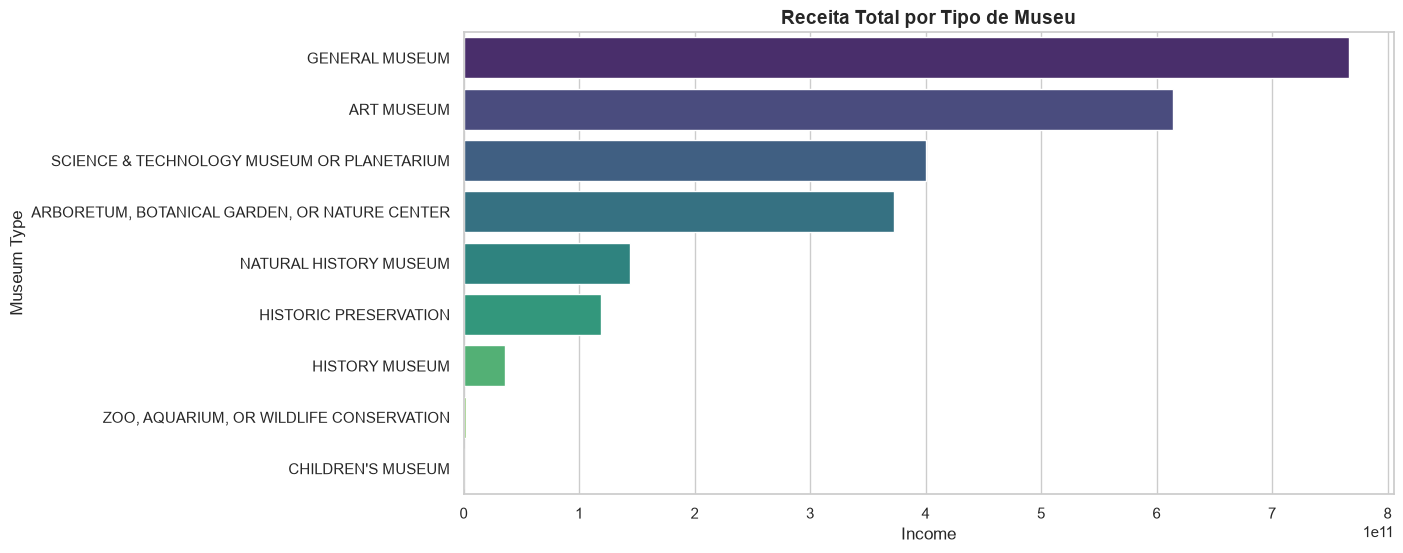

In [12]:
# Agrupamento correto
receita_por_tipo = df.groupby('Museum Type')['Income'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=receita_por_tipo, x='Income', y='Museum Type', palette="viridis")
plt.title('Receita Total por Tipo de Museu', fontsize=14, fontweight='bold')
plt.show()

Os resultados mostram que a receita não está distribuída igualmente entre todos os tipos de museus. Algumas categorias concentram valores muito superiores às demais, indicando diferenças significativas na capacidade financeira dessas instituições

- - - - - - - - - - - - - - - - - - - - 

### 3.3 Como os museus estão distribuídos geograficamente?

Além da análise financeira, também é interessante observar como os museus estão distribuídos entre os estados. Essa visualização permite identificar regiões com maior concentração de instituições e verificar se existe predominância de determinados tipos de museus.

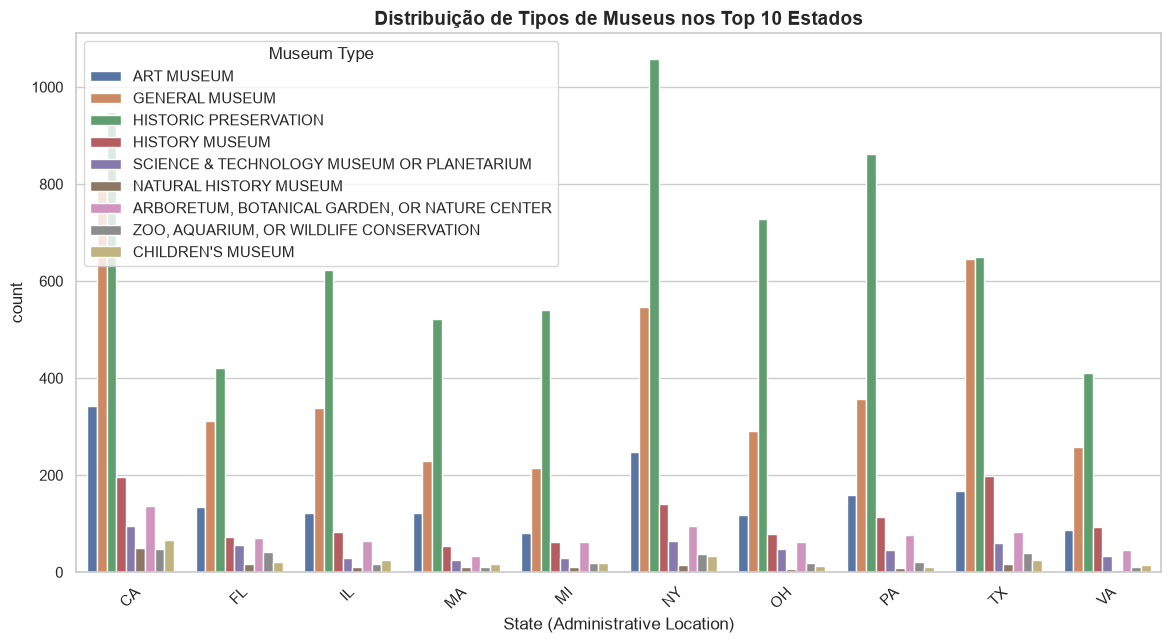

In [13]:
# Usando a coluna de estado administrativo que você tem
top_10_estados = df['State (Administrative Location)'].value_counts().head(10).index

plt.figure(figsize=(14, 7))
sns.countplot(data=df[df['State (Administrative Location)'].isin(top_10_estados)], 
              x='State (Administrative Location)', hue='Museum Type')
plt.title('Distribuição de Tipos de Museus nos Top 10 Estados', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

Observa-se que alguns estados apresentam uma concentração significativamente maior de museus do que outros. Além disso, a variedade de tipos também muda entre os estados, mostrando que o cenário cultural não é homogêneo.

- - - - - - - - - - - - - - - - - - - - 

### 3.4 Existem instituições que fogem completamente do padrão?

Como observado nas análises anteriores, existe uma grande diferença entre as receitas das instituições. Para verificar esse comportamento de forma mais clara, foi construído um boxplot, permitindo identificar possíveis valores extremos (outliers).

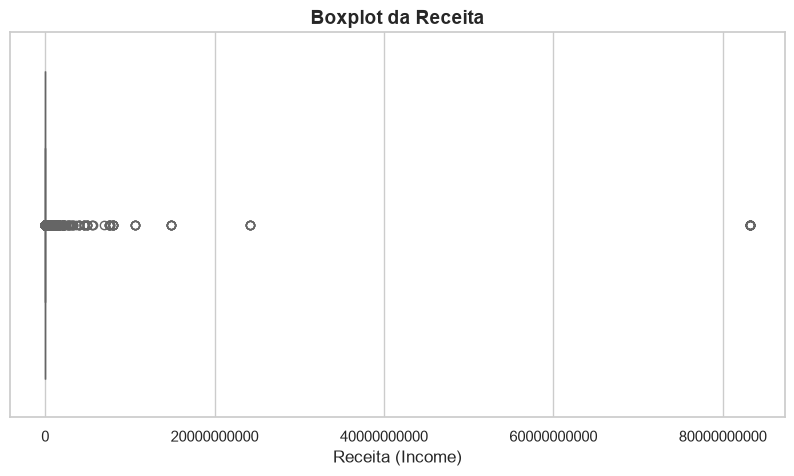

O museu com maior receita é do tipo SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM no estado de AZ.


In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Income', color="coral") 
plt.title('Boxplot da Receita', fontsize=14, fontweight='bold')
plt.xlabel('Receita (Income)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()
museu_mais_rico = df.loc[df['Income'].idxmax()]
print(f"O museu com maior receita é do tipo {museu_mais_rico['Museum Type']} no estado de {museu_mais_rico['State (Administrative Location)']}.")

O boxplot mostra que existem instituições com receitas muito acima da maioria. Isso indica uma forte concentração financeira, sugerindo que poucas organizações possuem um peso muito maior dentro do setor.

## 5. Conclusões e Considerações Finais

Ao longo deste projeto foi possível conhecer melhor a base de dados dos museus, identificar inconsistências e realizar os tratamentos necessários para tornar os dados mais confiáveis.
A análise mostrou que existem diferenças significativas entre os tipos de museus em relação à receita, além de uma distribuição geográfica bastante variada entre os estados. Também foi possível observar a presença de valores extremos, indicando que poucas instituições concentram grande parte dos recursos financeiros.
Com a base tratada e organizada, os dados ficam prontos para serem utilizados em futuras análises e na construção de dashboards, facilitando a visualização das informações e auxiliando na tomada de decisão.

## 6. Metodologia de Desenvolvimento e Uso de IA
Durante o desenvolvimento deste projeto foram utilizadas ferramentas de Inteligência Artificial, como ChatGPT e Gemini, para auxiliar na compreensão da sintaxe do Jupyter Notebook, esclarecer dúvidas sobre funções da biblioteca Pandas e apoiar a organização do relatório.
